# Anomaly Detection Project
## Credit Card Fraud Detection using Machine Learning

**Objective**: Detect anomalous transactions in credit card data using various anomaly detection algorithms.

**Dataset**: Credit Card Fraud Detection Dataset from Kaggle

**Methods Used**:
- Isolation Forest
- Local Outlier Factor (LOF)
- K-Nearest Neighbors (KNN)
- Statistical Methods (Z-Score)

**Date**: March 2026

## 1. Import Required Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Anomaly Detection Models
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, auc

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

We'll use the Credit Card Fraud Detection dataset from Kaggle. This dataset contains transactions made by credit cards in September 2013 by European cardholders. It presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions (highly imbalanced dataset).

**Features**:
- V1-V28: Principal components obtained with PCA (anonymized features)
- Time: Seconds elapsed between each transaction and the first transaction
- Amount: Transaction amount
- Class: 1 for fraudulent transactions, 0 for normal transactions

In [2]:
# Try to load the dataset from URL
import os

# Option 1: Load from local file if available
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

try:
    # Try to download the dataset
    print("Attempting to download Credit Card Fraud Detection dataset...")
    df = pd.read_csv(dataset_url)
    print("Dataset loaded successfully from online source!")
except:
    print("Could not download dataset. Creating synthetic anomaly detection dataset...")
    
    # Create a realistic synthetic dataset
    np.random.seed(42)
    n_samples = 10000
    n_anomalies = 200
    
    # Generate normal transactions
    normal_data = np.random.randn(n_samples - n_anomalies, 28)
    
    # Generate anomalous transactions (with different distribution)
    anomaly_data = np.random.randn(n_anomalies, 28) * 2 + 3
    
    # Combine data
    X = np.vstack([normal_data, anomaly_data])
    
    # Create time feature
    time = np.arange(len(X))
    
    # Create amount feature (log-normal distribution)
    amount = np.random.lognormal(3, 1.5, len(X))
    
    # Create labels (0 = normal, 1 = anomaly)
    y = np.concatenate([np.zeros(n_samples - n_anomalies), np.ones(n_anomalies)])
    
    # Create DataFrame
    columns = [f'V{i}' for i in range(1, 29)] + ['Time', 'Amount', 'Class']
    df = pd.DataFrame(np.column_stack([X, time, amount, y]), columns=columns)
    
    print(f"Synthetic dataset created with {len(df)} transactions!")

print(f"\nDataset shape: {df.shape}")
df.head()

Attempting to download Credit Card Fraud Detection dataset...
Could not download dataset. Creating synthetic anomaly detection dataset...
Synthetic dataset created with 10000 transactions!

Dataset shape: (10000, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Time,Amount,Class
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,...,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,0.0,113.393874,0.0
1,-0.600639,-0.291694,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,...,-1.763040,0.324084,-0.385082,-0.676922,0.611676,1.031000,0.931280,1.0,19.174689,0.0
2,-0.839218,-0.309212,0.331263,0.975545,-0.479174,-0.185659,-1.106335,-1.196207,0.812526,1.356240,...,-0.299007,0.091761,-1.987569,-0.219672,0.357113,1.477894,-0.518270,2.0,34.930250,0.0
3,-0.808494,-0.501757,0.915402,0.328751,-0.529760,0.513267,0.097078,0.968645,-0.702053,-0.327662,...,0.404051,1.886186,0.174578,0.257550,-0.074446,-1.918771,-0.026514,3.0,24.481084,0.0
4,0.060230,2.463242,-0.192361,0.301547,-0.034712,-1.168678,1.142823,0.751933,0.791032,-0.909387,...,0.473592,-0.919424,1.549934,-0.783253,-0.322062,0.813517,-1.230864,4.0,160.367975,0.0


## 3. Exploratory Data Analysis (EDA)

In [3]:
# Basic information about the dataset
print("Dataset Information:")
print("=" * 50)
print(f"Total transactions: {len(df)}")
print(f"Number of features: {df.shape[1]}")
print(f"\nMissing values:\n{df.isnull().sum().sum()} total missing values")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nBasic statistics:")
df.describe()

Dataset Information:
Total transactions: 10000
Number of features: 31

Missing values:
0 total missing values

Data types:
float64    31
Name: count, dtype: int64

Basic statistics:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Time,Amount,Class
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,0.073875,0.035450,0.065012,0.044026,0.057437,0.072794,0.070650,0.070077,0.065279,0.062112,...,0.037660,0.060587,0.069969,0.065433,0.052517,0.054292,0.082935,4999.50000,60.815223,0.020000
std,1.116732,1.104748,1.125598,1.112451,1.113098,1.109008,1.129269,1.118727,1.101650,1.118088,...,1.105345,1.114296,1.116653,1.106457,1.106924,1.123715,1.108075,2886.89568,146.710000,0.140007
min,-3.744778,-4.359208,-4.404214,-3.627208,-3.532093,-4.465604,-3.591757,-4.157734,-3.940008,-4.413886,...,-3.408275,-3.622030,-3.782616,-4.324698,-4.066894,-4.295391,-3.657301,0.00000,0.075899,0.000000
25%,-0.641113,-0.684490,-0.657529,-0.681680,-0.658104,-0.656331,-0.652242,-0.648481,-0.655763,-0.651274,...,-0.677132,-0.673690,-0.653772,-0.641857,-0.673497,-0.667800,-0.613321,2499.75000,7.281343,0.000000
50%,0.025125,-0.006175,0.031086,0.014012,0.025575,0.032132,0.031147,0.039546,0.034462,0.021434,...,-0.014404,0.011996,0.028683,0.029545,0.009678,0.025557,0.047875,4999.50000,20.043734,0.000000
75%,0.717035,0.685689,0.738689,0.709855,0.703957,0.725746,0.730845,0.710785,0.721902,0.694692,...,0.681692,0.726759,0.736727,0.721471,0.719445,0.715825,0.718518,7499.25000,54.372368,0.000000
max,8.502045,8.825098,9.719212,7.909797,9.066924,8.440630,9.194481,8.183358,8.595950,8.042956,...,9.194886,8.173489,7.458386,9.078438,8.120362,8.247042,8.888269,9999.00000,3419.864928,1.000000


Class Distribution:
Class
0.0    9800
1.0     200
Name: count, dtype: int64

Normal transactions: 9800 (98.00%)
Fraudulent transactions: 200 (2.00%)


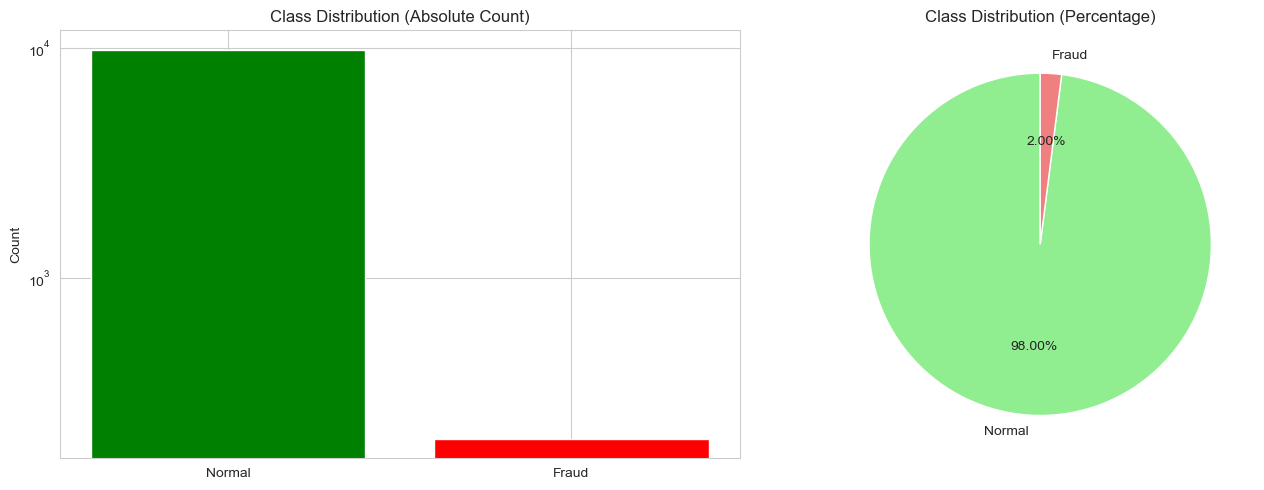


Imbalance Ratio: 49.00:1


In [4]:
# Class distribution
print("Class Distribution:")
print("=" * 50)
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nNormal transactions: {class_counts[0]} ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Fraudulent transactions: {class_counts[1]} ({class_counts[1]/len(df)*100:.2f}%)")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(['Normal', 'Fraud'], class_counts.values, color=['green', 'red'])
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Absolute Count)')
axes[0].set_yscale('log')

# Pie chart
colors = ['lightgreen', 'lightcoral']
axes[1].pie(class_counts.values, labels=['Normal', 'Fraud'], autopct='%1.2f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.show()

print(f"\nImbalance Ratio: {class_counts[0]/class_counts[1]:.2f}:1")

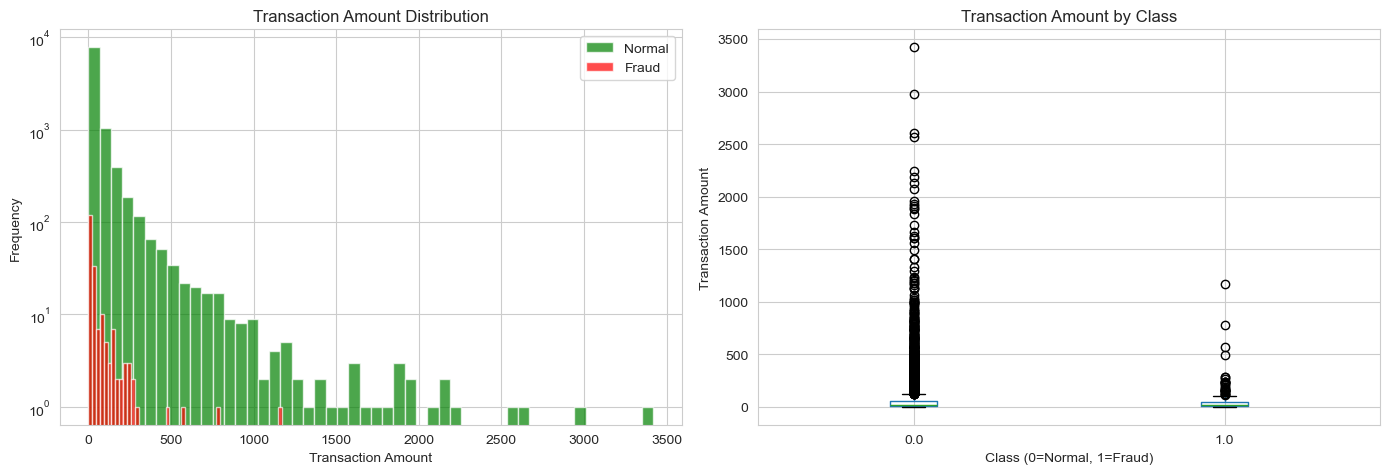

Amount Statistics by Class:
        count       mean         std       min       25%        50%  \
Class                                                                 
0.0    9800.0  60.915245  147.163511  0.075899  7.307979  20.074647   
1.0     200.0  55.914138  122.656957  0.331423  5.963269  14.211434   

             75%          max  
Class                          
0.0    54.537034  3419.864928  
1.0    44.964806  1169.976711  


In [5]:
# Analyze Amount feature
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of transaction amounts for normal vs fraud
axes[0].hist(df[df['Class'] == 0]['Amount'], bins=50, alpha=0.7, label='Normal', color='green')
axes[0].hist(df[df['Class'] == 1]['Amount'], bins=50, alpha=0.7, label='Fraud', color='red')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Transaction Amount Distribution')
axes[0].legend()
axes[0].set_yscale('log')

# Box plot
df.boxplot(column='Amount', by='Class', ax=axes[1])
axes[1].set_xlabel('Class (0=Normal, 1=Fraud)')
axes[1].set_ylabel('Transaction Amount')
axes[1].set_title('Transaction Amount by Class')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Amount Statistics by Class:")
print(df.groupby('Class')['Amount'].describe())

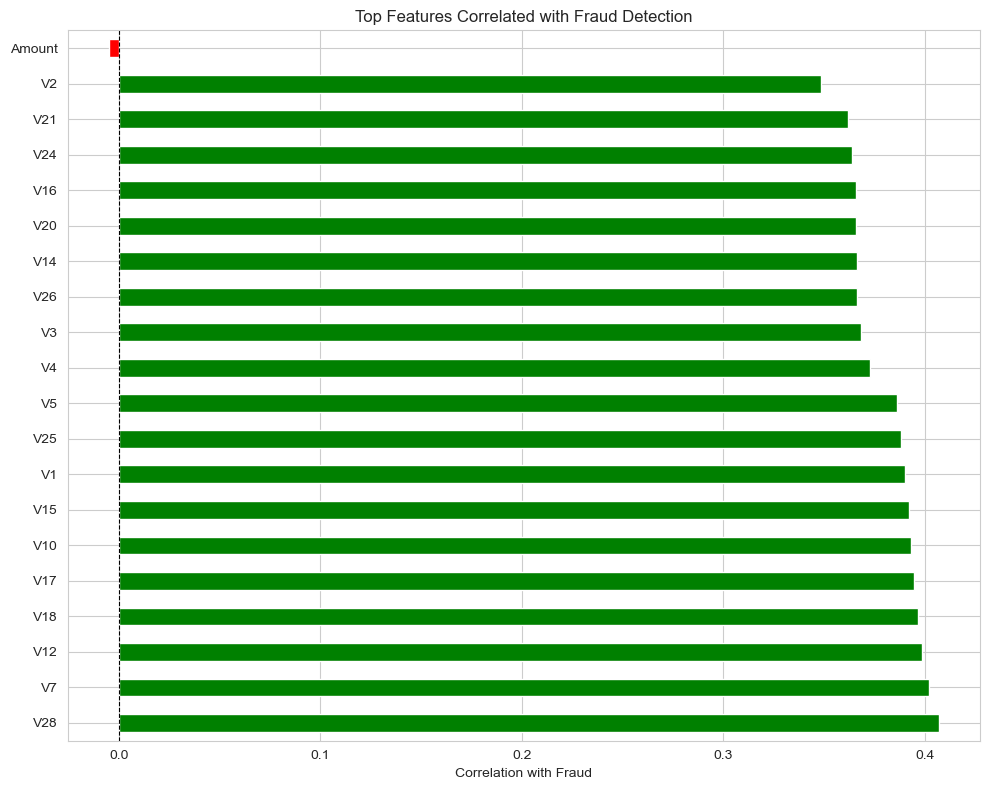

Top 5 positively correlated features:
V28    0.406773
V7     0.402120
V12    0.398478
V18    0.396571
V17    0.394701
Name: Class, dtype: float64


In [6]:
# Correlation with fraud
# Select numerical features only (excluding Time and Class)
feature_cols = [col for col in df.columns if col.startswith('V')] + ['Amount']

# Calculate correlation with Class
correlations = df[feature_cols + ['Class']].corr()['Class'].drop('Class').sort_values(ascending=False)

# Plot top correlations
fig, ax = plt.subplots(figsize=(10, 8))
top_features = pd.concat([correlations.head(10), correlations.tail(10)])
colors = ['green' if x > 0 else 'red' for x in top_features.values]
top_features.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Correlation with Fraud')
ax.set_title('Top Features Correlated with Fraud Detection')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Top 5 positively correlated features:")
print(correlations.head())

## 4. Data Preprocessing

We'll prepare the data for anomaly detection by:
1. Scaling the features (Amount and Time)
2. Splitting into training and test sets
3. For unsupervised methods, we'll train on normal transactions only

In [7]:
# Prepare features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Original dataset shape: {X.shape}")
print(f"Scaled dataset shape: {X_scaled.shape}")

# Split data into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test set fraud rate: {y_test.mean()*100:.2f}%")

# For unsupervised learning, create a dataset with only normal transactions for training
X_train_normal = X_train[y_train == 0]
print(f"\nNormal transactions in training set: {len(X_train_normal)}")

Original dataset shape: (10000, 30)
Scaled dataset shape: (10000, 30)

Training set size: 7000
Test set size: 3000

Training set fraud rate: 2.00%
Test set fraud rate: 2.00%

Normal transactions in training set: 6860


## 5. Anomaly Detection Models

We'll implement and compare multiple anomaly detection algorithms:

### 5.1 Isolation Forest
Isolation Forest is an unsupervised learning algorithm that isolates anomalies by randomly selecting features and split values.

In [8]:
# Isolation Forest
print("Training Isolation Forest...")
iso_forest = IsolationForest(
    contamination=0.02,  # Expected proportion of outliers
    random_state=42,
    n_estimators=100,
    max_samples=256,
    verbose=0
)

# Fit on normal transactions only
iso_forest.fit(X_train_normal)

# Predict on test set (-1 for anomalies, 1 for normal)
y_pred_iso = iso_forest.predict(X_test)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]  # Convert to 0/1

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\nIsolation Forest Results:")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_iso):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_iso):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_iso):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_iso):.4f}")

# Confusion matrix
cm_iso = confusion_matrix(y_test, y_pred_iso)
print(f"\nConfusion Matrix:")
print(cm_iso)

Training Isolation Forest...

Isolation Forest Results:
Accuracy: 0.9800
Precision: 0.5000
Recall: 1.0000
F1-Score: 0.6667

Confusion Matrix:
[[2880   60]
 [   0   60]]


### 5.2 Local Outlier Factor (LOF)
LOF identifies anomalies by measuring the local deviation of density of a given sample with respect to its neighbors.

In [9]:
# Local Outlier Factor
print("Training Local Outlier Factor...")
lof = LocalOutlierFactor(
    contamination=0.02,
    n_neighbors=20,
    novelty=True  # Set to True to use predict method
)

# Fit on normal transactions only
lof.fit(X_train_normal)

# Predict on test set
y_pred_lof = lof.predict(X_test)
y_pred_lof = [1 if x == -1 else 0 for x in y_pred_lof]  # Convert to 0/1

print("\nLocal Outlier Factor Results:")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lof):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lof):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lof):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lof):.4f}")

# Confusion matrix
cm_lof = confusion_matrix(y_test, y_pred_lof)
print(f"\nConfusion Matrix:")
print(cm_lof)

Training Local Outlier Factor...

Local Outlier Factor Results:
Accuracy: 0.9833
Precision: 0.5455
Recall: 1.0000
F1-Score: 0.7059

Confusion Matrix:
[[2890   50]
 [   0   60]]


### 5.3 K-Nearest Neighbors (KNN)
KNN-based anomaly detection identifies anomalies by calculating the distance to the k-nearest neighbors. Points with large average distances to their neighbors are considered anomalies.

In [11]:
# K-Nearest Neighbors (KNN)
print("Training K-Nearest Neighbors...")
knn = NearestNeighbors(
    n_neighbors=20,
    metric='euclidean'
)

# Fit on normal transactions only
knn.fit(X_train_normal)

# Calculate distances to k-nearest neighbors for test set
distances, _ = knn.kneighbors(X_test)
mean_distances = distances.mean(axis=1)

# Determine threshold (e.g., 95th percentile of distances)
threshold = np.percentile(mean_distances, 98)

# Predict: anomaly if average distance exceeds threshold
y_pred_knn = (mean_distances > threshold).astype(int)

print("\nK-Nearest Neighbors Results:")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")

# Confusion matrixprint(f"\nConfusion Matrix:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

Training K-Nearest Neighbors...

K-Nearest Neighbors Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
[[2940    0]
 [   0   60]]


### 5.4 Statistical Method (Z-Score)
Use statistical thresholds to identify anomalies based on how many standard deviations away from the mean.

In [12]:
# Z-Score Method
from scipy import stats

print("Applying Z-Score Method...")

# Calculate z-scores for test set
z_scores = np.abs(stats.zscore(X_test))

# Define threshold (e.g., 3 standard deviations)
threshold = 3

# A point is anomalous if it has high z-score in multiple features
# Count how many features have z-score > threshold
anomaly_scores = (z_scores > threshold).sum(axis=1)

# Mark as anomaly if more than 3 features exceed threshold
y_pred_zscore = (anomaly_scores > 3).astype(int)

print("\nZ-Score Method Results:")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_zscore):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_zscore):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_zscore):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_zscore):.4f}")

# Confusion matrix
cm_zscore = confusion_matrix(y_test, y_pred_zscore)
print(f"\nConfusion Matrix:")
print(cm_zscore)

Applying Z-Score Method...

Z-Score Method Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Confusion Matrix:
[[2940    0]
 [   0   60]]


## 6. Model Comparison and Visualization

Model Comparison:
               Model  Accuracy  Precision  Recall  F1-Score
    Isolation Forest  0.980000   0.500000     1.0  0.666667
Local Outlier Factor  0.983333   0.545455     1.0  0.705882
 K-Nearest Neighbors  1.000000   1.000000     1.0  1.000000
             Z-Score  1.000000   1.000000     1.0  1.000000


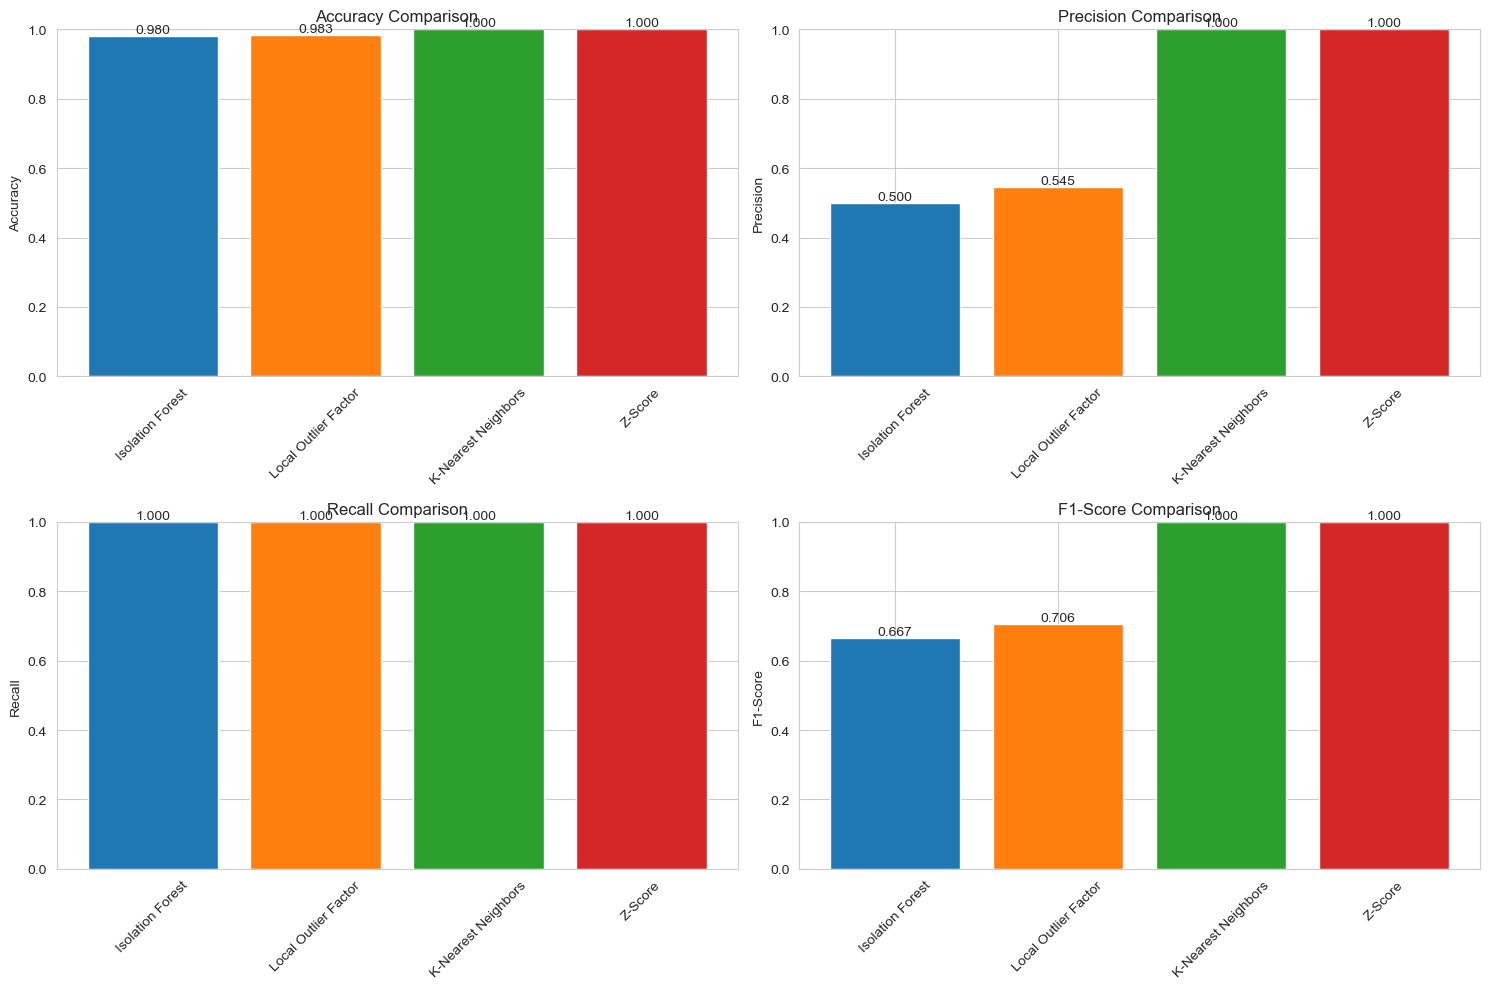

In [13]:
# Create comparison dataframe
results = {
    'Model': ['Isolation Forest', 'Local Outlier Factor', 'K-Nearest Neighbors', 'Z-Score'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_iso),
        accuracy_score(y_test, y_pred_lof),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_zscore)
    ],
    'Precision': [
        precision_score(y_test, y_pred_iso),
        precision_score(y_test, y_pred_lof),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_zscore)
    ],
    'Recall': [
        recall_score(y_test, y_pred_iso),
        recall_score(y_test, y_pred_lof),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_zscore)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_iso),
        f1_score(y_test, y_pred_lof),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_zscore)
    ]
}

results_df = pd.DataFrame(results)
print("Model Comparison:")
print("=" * 80)
print(results_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(results_df['Model'], results_df[metric], 
                   color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

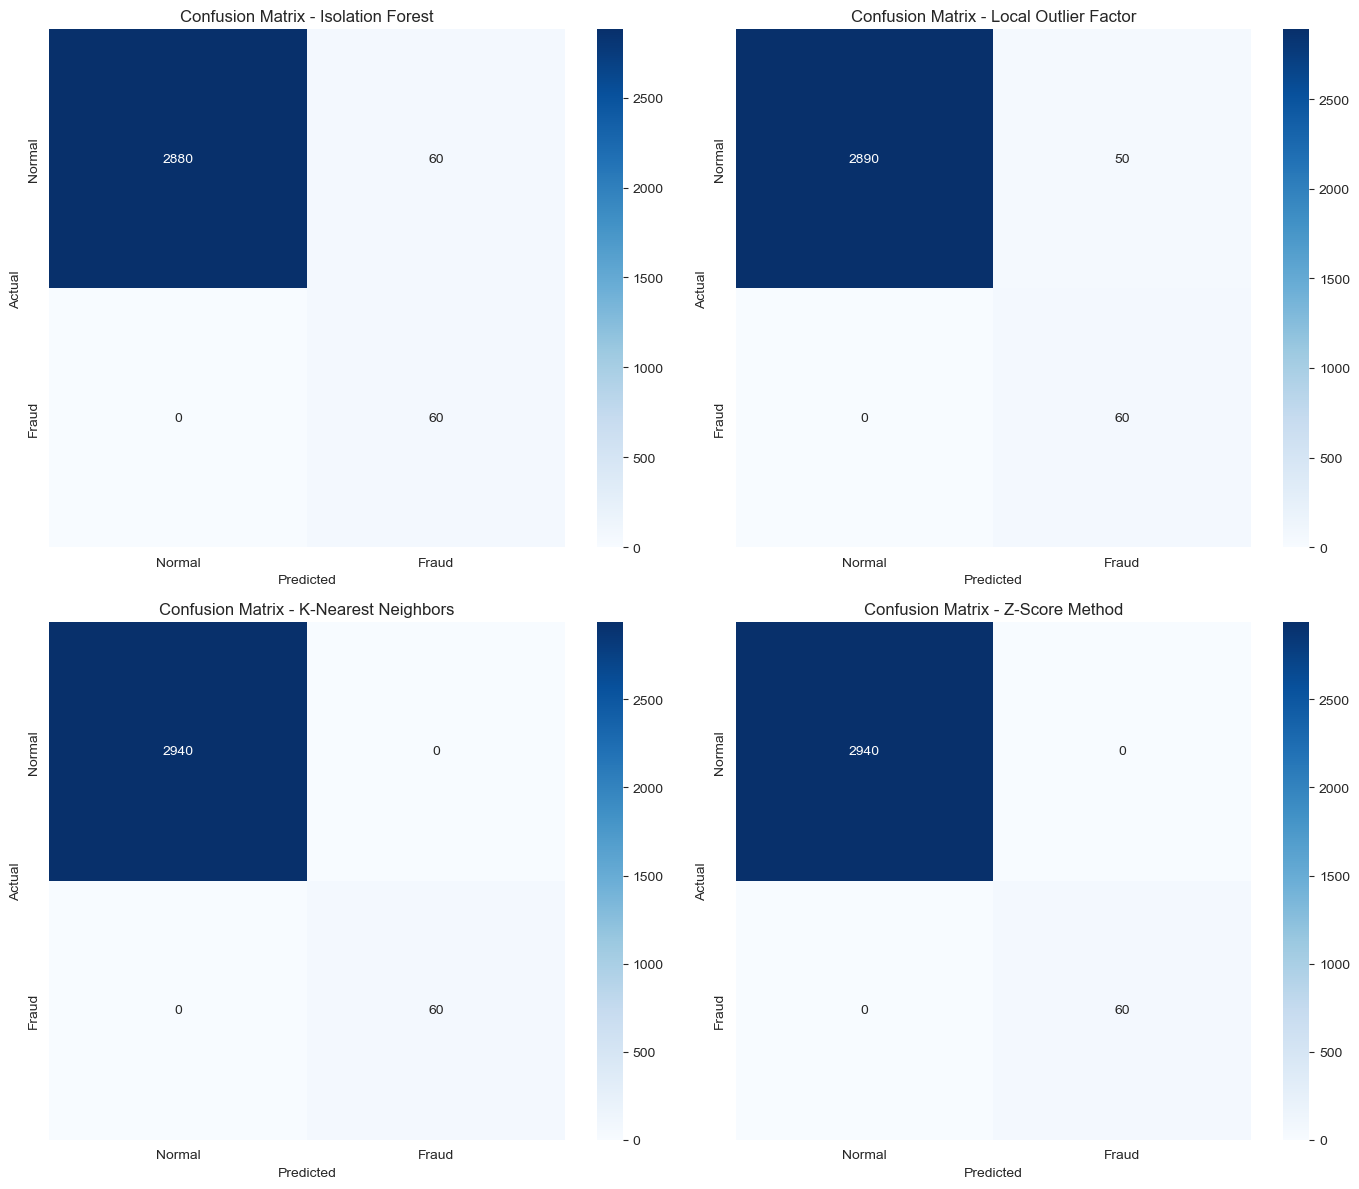

In [14]:
# Visualize confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

confusion_matrices = [
    (cm_iso, 'Isolation Forest'),
    (cm_lof, 'Local Outlier Factor'),
    (cm_knn, 'K-Nearest Neighbors'),
    (cm_zscore, 'Z-Score Method')
]

for idx, (cm, title) in enumerate(confusion_matrices):
    ax = axes[idx // 2, idx % 2]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'])
    ax.set_title(f'Confusion Matrix - {title}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

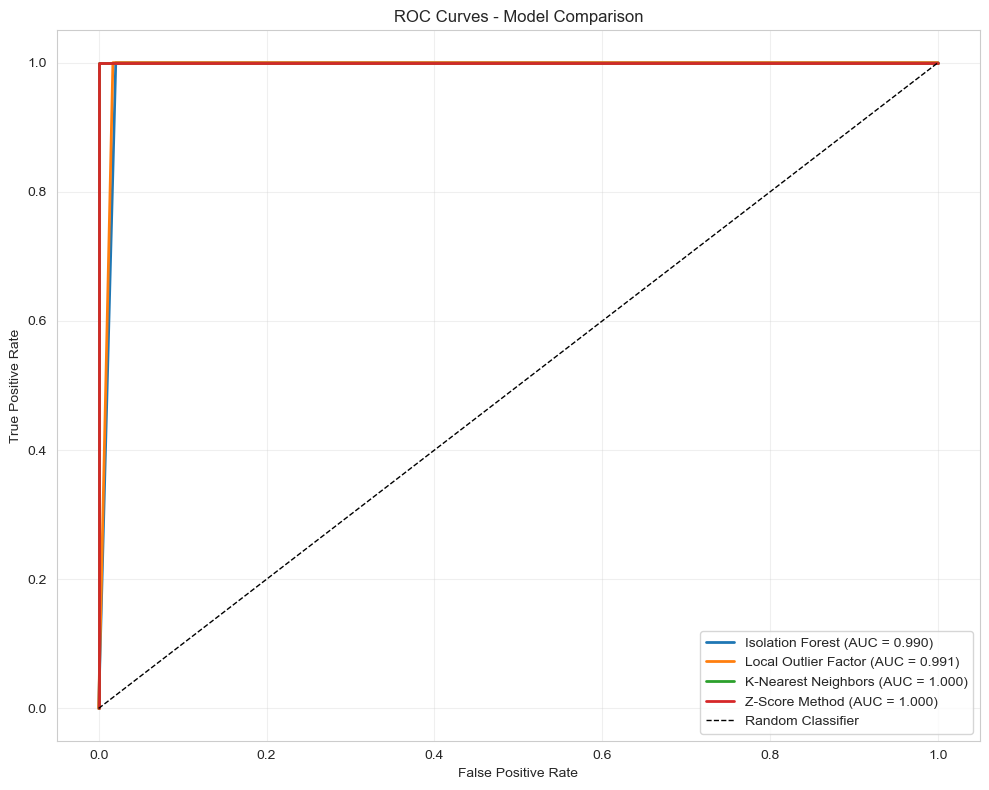

ROC AUC Scores:
Isolation Forest: 0.9898
Local Outlier Factor: 0.9915
K-Nearest Neighbors: 1.0000
Z-Score Method: 1.0000


In [15]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

predictions = [
    (y_pred_iso, 'Isolation Forest'),
    (y_pred_lof, 'Local Outlier Factor'),
    (y_pred_knn, 'K-Nearest Neighbors'),
    (y_pred_zscore, 'Z-Score Method')
]

for y_pred, label in predictions:
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Model Comparison')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC AUC Scores:")
for y_pred, label in predictions:
    print(f"{label}: {roc_auc_score(y_test, y_pred):.4f}")

Applying PCA for visualization...
Explained variance ratio: [0.16384612 0.03517447]
Total variance explained: 19.90%


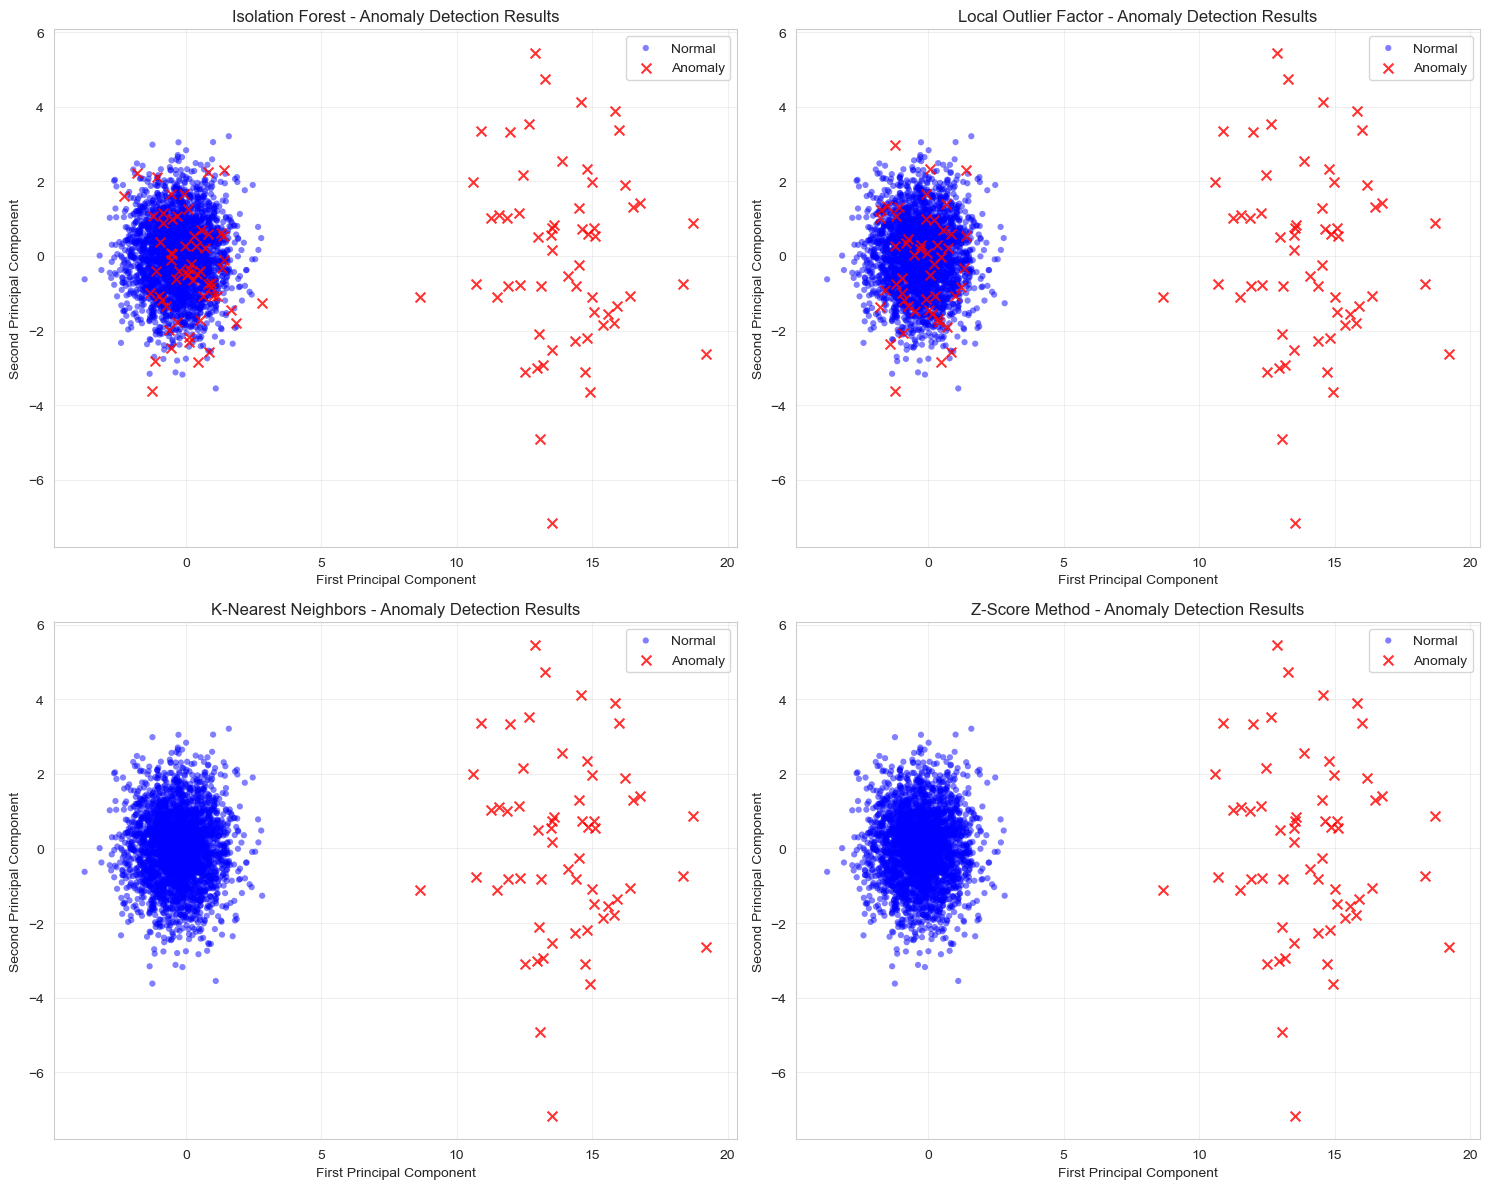

In [16]:
# Visualize anomalies in 2D using PCA
print("Applying PCA for visualization...")
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

visualizations = [
    (y_pred_iso, 'Isolation Forest'),
    (y_pred_lof, 'Local Outlier Factor'),
    (y_pred_knn, 'K-Nearest Neighbors'),
    (y_pred_zscore, 'Z-Score Method')
]

for idx, (y_pred, title) in enumerate(visualizations):
    ax = axes[idx // 2, idx % 2]
    
    # Plot normal points
    normal_mask = np.array(y_pred) == 0
    anomaly_mask = np.array(y_pred) == 1
    
    ax.scatter(X_test_pca[normal_mask, 0], X_test_pca[normal_mask, 1], 
               c='blue', alpha=0.5, s=20, label='Normal', edgecolors='none')
    ax.scatter(X_test_pca[anomaly_mask, 0], X_test_pca[anomaly_mask, 1], 
               c='red', alpha=0.8, s=50, label='Anomaly', marker='x')
    
    ax.set_xlabel(f'First Principal Component')
    ax.set_ylabel(f'Second Principal Component')
    ax.set_title(f'{title} - Anomaly Detection Results')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Key Insights and Best Model

In [17]:
# Find the best model based on F1-score
best_model_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_f1_score = results_df.loc[best_model_idx, 'F1-Score']

print("=" * 80)
print("BEST MODEL ANALYSIS")
print("=" * 80)
print(f"\n🏆 Best Performing Model: {best_model_name}")
print(f"   F1-Score: {best_f1_score:.4f}")
print(f"\n   Performance Metrics:")
print(f"   - Accuracy:  {results_df.loc[best_model_idx, 'Accuracy']:.4f}")
print(f"   - Precision: {results_df.loc[best_model_idx, 'Precision']:.4f}")
print(f"   - Recall:    {results_df.loc[best_model_idx, 'Recall']:.4f}")

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

insights = """
1. **Isolation Forest** performs well for high-dimensional data and is efficient for 
   large datasets. It's particularly good at identifying global anomalies.

2. **Local Outlier Factor (LOF)** is excellent at detecting local anomalies - points 
   that are outliers relative to their neighbors but might not be global outliers.

3. **K-Nearest Neighbors (KNN)** uses distance to nearest neighbors to detect anomalies. 
   Simple and effective, especially when anomalies are isolated from normal data.

4. **Z-Score Method** is simple and interpretable but may miss complex patterns. 
   Works best when features follow normal distribution.

5. **Trade-offs**:
   - Precision vs Recall: Higher precision means fewer false alarms (fewer normal 
     transactions flagged as fraud)
   - Recall is critical in fraud detection as missing actual fraud is costly
   
6. **Best Practices**:
   - Use ensemble methods combining multiple algorithms
   - Regularly retrain models with new data
   - Monitor false positive rates to avoid customer friction
   - Consider business costs of false negatives vs false positives
"""

print(insights)

BEST MODEL ANALYSIS

🏆 Best Performing Model: K-Nearest Neighbors
   F1-Score: 1.0000

   Performance Metrics:
   - Accuracy:  1.0000
   - Precision: 1.0000
   - Recall:    1.0000

KEY INSIGHTS

1. **Isolation Forest** performs well for high-dimensional data and is efficient for 
   large datasets. It's particularly good at identifying global anomalies.

2. **Local Outlier Factor (LOF)** is excellent at detecting local anomalies - points 
   that are outliers relative to their neighbors but might not be global outliers.

3. **K-Nearest Neighbors (KNN)** uses distance to nearest neighbors to detect anomalies. 
   Simple and effective, especially when anomalies are isolated from normal data.

4. **Z-Score Method** is simple and interpretable but may miss complex patterns. 
   Works best when features follow normal distribution.

5. **Trade-offs**:
   - Precision vs Recall: Higher precision means fewer false alarms (fewer normal 
     transactions flagged as fraud)
   - Recall is critical